# NHS A&E Patient Flow Analysis (2025–2026)

## Project Overview

This project analyses NHS England Accident & Emergency (A&E) operational performance data from April 2025 to March 2026.

The project focuses on:
- A&E attendance trends
- 4-hour operational performance
- Decision-to-admit (DTA) waiting times
- Provider-level operational variation
- Indicators of patient-flow pressure across NHS organisations

The analysis uses publicly available NHS England monthly A&E operational datasets at provider organisation level.

## Project Objectives

The objectives of this project are to:

1. Analyse monthly trends in A&E attendances and operational performance
2. Investigate the relationship between emergency demand and 4-hour performance
3. Explore provider-level variation across NHS organisations
4. Analyse decision-to-admit waiting times as indicators of inpatient flow pressure
5. Demonstrate healthcare operational analytics using Python and NHS England data

## Dataset Information

Source:
- NHS England — A&E Attendances and Emergency Admissions Dataset

Coverage:
- April 2025 to March 2026
- Provider-level NHS operational data
- Multiple A&E department types

Key variables include:
- Total A&E attendances
- Attendances over 4 hours
- Decision-to-admit waits
- Emergency admissions

## Why This Project Matters

A&E waiting times and admitted-patient delays remain major operational challenges within NHS urgent and emergency care services.

This project aims to explore operational pressures and patient-flow challenges using real NHS England data while demonstrating practical healthcare analytics techniques relevant to NHS operational and performance analysis roles.

## Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)

## Loading NHS England Monthly Datasets

In [2]:
file_paths = [
    r"C:\Users\raahu\OneDrive\Desktop\nhs-ae-patient-flow-analysis\data_raw\ae_2025_04.csv",
    r"C:\Users\raahu\OneDrive\Desktop\nhs-ae-patient-flow-analysis\data_raw\ae_2025_05.csv",
    r"C:\Users\raahu\OneDrive\Desktop\nhs-ae-patient-flow-analysis\data_raw\ae_2025_06.csv",
    r"C:\Users\raahu\OneDrive\Desktop\nhs-ae-patient-flow-analysis\data_raw\ae_2025_07.csv",
    r"C:\Users\raahu\OneDrive\Desktop\nhs-ae-patient-flow-analysis\data_raw\ae_2025_08.csv",
    r"C:\Users\raahu\OneDrive\Desktop\nhs-ae-patient-flow-analysis\data_raw\ae_2025_09.csv",
    r"C:\Users\raahu\OneDrive\Desktop\nhs-ae-patient-flow-analysis\data_raw\ae_2025_10.csv",
    r"C:\Users\raahu\OneDrive\Desktop\nhs-ae-patient-flow-analysis\data_raw\ae_2025_11.csv",
    r"C:\Users\raahu\OneDrive\Desktop\nhs-ae-patient-flow-analysis\data_raw\ae_2025_12.csv",
    r"C:\Users\raahu\OneDrive\Desktop\nhs-ae-patient-flow-analysis\data_raw\ae_2026_01.csv",
    r"C:\Users\raahu\OneDrive\Desktop\nhs-ae-patient-flow-analysis\data_raw\ae_2026_02.csv",
    r"C:\Users\raahu\OneDrive\Desktop\nhs-ae-patient-flow-analysis\data_raw\ae_2026_03.csv"
]

df_list = []

for file in file_paths:
    temp_df = pd.read_csv(file)
    df_list.append(temp_df)

ae_raw = pd.concat(df_list, ignore_index=True)

ae_raw.shape

(2397, 22)

## Initial Dataset Validation

In [3]:
ae_raw.head()

,Period,Org Code,Parent Org,Org name,A&E attendances Type 1,A&E attendances Type 2,A&E attendances Other A&E Department,A&E attendances Booked Appointments Type 1,A&E attendances Booked Appointments Type 2,A&E attendances Booked Appointments Other Department,Attendances over 4hrs Type 1,Attendances over 4hrs Type 2,Attendances over 4hrs Other Department,Attendances over 4hrs Booked Appointments Type 1,Attendances over 4hrs Booked Appointments Type 2,Attendances over 4hrs Booked Appointments Other Department,Patients who have waited 4-12 hs from DTA to admission,Patients who have waited 12+ hrs from DTA to admission,Emergency admissions via A&E - Type 1,Emergency admissions via A&E - Type 2,Emergency admissions via A&E - Other A&E department,Other emergency admissions
0,MSitAE-APRIL-2025,NDJ,NHS ENGLAND SOUTH EAST,FIRST COMMUNITY HEALTH AND CARE CIC,0,0,2350,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,MSitAE-APRIL-2025,NTV0B,NHS ENGLAND SOUTH EAST,ASHFORD WALK-IN-CENTRE,0,0,2333,0,0,0,0,0,49,0,0,0,0,0,0,0,0,0
2,MSitAE-APRIL-2025,NTV0W,NHS ENGLAND SOUTH EAST,WOKING WALK IN CENTRE,0,0,2528,0,0,0,0,0,58,0,0,0,0,0,0,0,0,0
3,MSitAE-APRIL-2025,Y02615,NHS ENGLAND MIDLANDS,SOUTH BIRMINGHAM GP WALK IN CENTRE,0,0,6628,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,MSitAE-APRIL-2025,AQN04,NHS ENGLAND SOUTH EAST,PHL LYMINGTON UTC,0,0,3297,0,0,12,0,0,42,0,0,0,0,0,0,0,0,0


In [4]:
ae_raw.shape

(2397, 22)

In [5]:
ae_raw.columns.tolist()

['Period',
 'Org Code',
 'Parent Org',
 'Org name',
 'A&E attendances Type 1',
 'A&E attendances Type 2',
 'A&E attendances Other A&E Department',
 'A&E attendances Booked Appointments Type 1',
 'A&E attendances Booked Appointments Type 2',
 'A&E attendances Booked Appointments Other Department',
 'Attendances over 4hrs Type 1',
 'Attendances over 4hrs Type 2',
 'Attendances over 4hrs Other Department',
 'Attendances over 4hrs Booked Appointments Type 1',
 'Attendances over 4hrs Booked Appointments Type 2',
 'Attendances over 4hrs Booked Appointments Other Department',
 'Patients who have waited 4-12 hs from DTA to admission',
 'Patients who have waited 12+ hrs from DTA to admission',
 'Emergency admissions via A&E - Type 1',
 'Emergency admissions via A&E - Type 2',
 'Emergency admissions via A&E - Other A&E department',
 'Other emergency admissions']

## Standardising Column Names

In [6]:
ae_raw.columns = (
    ae_raw.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

ae_raw.columns.tolist()

['period',
 'org_code',
 'parent_org',
 'org_name',
 'a&e_attendances_type_1',
 'a&e_attendances_type_2',
 'a&e_attendances_other_a&e_department',
 'a&e_attendances_booked_appointments_type_1',
 'a&e_attendances_booked_appointments_type_2',
 'a&e_attendances_booked_appointments_other_department',
 'attendances_over_4hrs_type_1',
 'attendances_over_4hrs_type_2',
 'attendances_over_4hrs_other_department',
 'attendances_over_4hrs_booked_appointments_type_1',
 'attendances_over_4hrs_booked_appointments_type_2',
 'attendances_over_4hrs_booked_appointments_other_department',
 'patients_who_have_waited_4-12_hs_from_dta_to_admission',
 'patients_who_have_waited_12+_hrs_from_dta_to_admission',
 'emergency_admissions_via_a&e_-_type_1',
 'emergency_admissions_via_a&e_-_type_2',
 'emergency_admissions_via_a&e_-_other_a&e_department',
 'other_emergency_admissions']

## Creating Working Dataset

In [7]:
ae = ae_raw.copy()

ae.shape

(2397, 22)

## Validating National Summary Rows

In [8]:
ae[
    ae["org_code"].astype(str).str.strip().str.upper() == "TOTAL"
]

,period,org_code,parent_org,org_name,a&e_attendances_type_1,a&e_attendances_type_2,a&e_attendances_other_a&e_department,a&e_attendances_booked_appointments_type_1,a&e_attendances_booked_appointments_type_2,a&e_attendances_booked_appointments_other_department,attendances_over_4hrs_type_1,attendances_over_4hrs_type_2,attendances_over_4hrs_other_department,attendances_over_4hrs_booked_appointments_type_1,attendances_over_4hrs_booked_appointments_type_2,attendances_over_4hrs_booked_appointments_other_department,patients_who_have_waited_4-12_hs_from_dta_to_admission,patients_who_have_waited_12+_hrs_from_dta_to_admission,emergency_admissions_via_a&e_-_type_1,emergency_admissions_via_a&e_-_type_2,emergency_admissions_via_a&e_-_other_a&e_department,other_emergency_admissions
198,TOTAL,TOTAL,TOTAL,TOTAL,1354959,49112,805616,33654,626,53454,544820,2227,24080,7638,42,515,87208,44648,390648,1418,4226,131938
399,TOTAL,TOTAL,TOTAL,TOTAL,1419306,50370,839622,34174,549,53508,555982,2262,23131,7821,35,504,87144,42891,403026,1440,5060,135602
601,TOTAL,TOTAL,TOTAL,TOTAL,1395330,50843,821993,33233,775,49407,539355,2030,25349,7516,13,546,79488,38683,395628,1389,4863,134061
803,TOTAL,TOTAL,TOTAL,TOTAL,1433180,52429,834765,35870,560,52062,534607,2407,23271,7553,23,443,80075,35467,412893,1443,5115,139941
1005,TOTAL,TOTAL,TOTAL,TOTAL,1351631,48479,782613,32239,605,51370,518160,2245,18635,7382,28,421,79917,35909,394548,1261,5111,125479
1207,TOTAL,TOTAL,TOTAL,TOTAL,1385429,50116,791957,32011,617,50092,543443,2122,22158,8221,29,418,84239,44765,395054,1343,5349,133834
1404,TOTAL,TOTAL,TOTAL,TOTAL,1449480,54142,810555,31742,614,51168,581850,2864,25926,8762,36,436,88420,54314,406835,1364,5511,140483
1602,TOTAL,TOTAL,TOTAL,TOTAL,1418397,49176,794353,30561,549,52824,566410,2432,27004,8662,43,611,83151,50648,390459,1314,4971,135003
1800,TOTAL,TOTAL,TOTAL,TOTAL,1407880,47040,785405,31041,482,55167,572137,2015,25269,8608,25,473,86988,50775,399046,1312,5020,136817
1998,Total,Total,Total,Total,1405298,50161,780500,30429,549,53329,603393,2457,23637,9026,27,442,89624,71517,395611,1399,4932,144194


In [9]:
ae[
    ae["org_code"].astype(str).str.strip().str.upper() == "TOTAL"
].shape

(12, 22)

## Removing National Summary Rows

In [10]:
ae = ae[
    ae["org_code"]
    .astype(str)
    .str.strip()
    .str.upper() != "TOTAL"
]

ae.shape

(2385, 22)

In [11]:
ae[
    ae["org_code"]
    .astype(str)
    .str.strip()
    .str.upper() == "TOTAL"
].shape

(0, 22)

In [12]:
ae["org_name"].value_counts().head(10)

org_name
FIRST COMMUNITY HEALTH AND CARE CIC                        12
ASHFORD WALK-IN-CENTRE                                     12
WOKING WALK IN CENTRE                                      12
SOUTH BIRMINGHAM GP WALK IN CENTRE                         12
PHL LYMINGTON UTC                                          12
LATHAM HOUSE MEDICAL PRACTICE                              12
SUMMERFIELD URGENT CARE CENTRE                             12
LIVERPOOL HEART AND CHEST HOSPITAL NHS FOUNDATION TRUST    12
HARROGATE AND DISTRICT NHS FOUNDATION TRUST                12
CORNWALL PARTNERSHIP NHS FOUNDATION TRUST                  12
Name: count, dtype: int64

## Validating Monthly Provider Counts

In [15]:
ae["period"].value_counts().sort_index()

period
MSitAE-APRIL-2025        198
MSitAE-AUGUST-2025       201
MSitAE-DECEMBER-2025     197
MSitAE-FEBRUARY-2026     197
MSitAE-JANUARY-2026      197
MSitAE-JULY-2025         201
MSitAE-JUNE-2025         201
MSitAE-MARCH-2026        199
MSitAE-MAY-2025          200
MSitAE-NOVEMBER-2025     197
MSitAE-OCTOBER-2025      196
MSitAE-SEPTEMBER-2025    201
Name: count, dtype: int64

## Cleaning and Validating Date Variables

In [16]:
# Clean period column
ae["period_clean"] = (
    ae["period"]
    .astype(str)
    .str.strip()
    .str.upper()
)

# Remove MSITAE- prefix
ae["period_clean"] = (
    ae["period_clean"]
    .str.replace("MSITAE-", "", regex=False)
)

# Convert to datetime
ae["period_date"] = pd.to_datetime(
    ae["period_clean"],
    format="%B-%Y"
)

# Create readable month label
ae["period_month"] = (
    ae["period_date"]
    .dt.strftime("%b %Y")
)

# Preview
ae[[
    "period",
    "period_clean",
    "period_date",
    "period_month"
]].head()

,period,period_clean,period_date,period_month
0,MSitAE-APRIL-2025,APRIL-2025,2025-04-01,Apr 2025
1,MSitAE-APRIL-2025,APRIL-2025,2025-04-01,Apr 2025
2,MSitAE-APRIL-2025,APRIL-2025,2025-04-01,Apr 2025
3,MSitAE-APRIL-2025,APRIL-2025,2025-04-01,Apr 2025
4,MSitAE-APRIL-2025,APRIL-2025,2025-04-01,Apr 2025


In [17]:
ae["period_month"].value_counts().sort_index()

period_month
Apr 2025    198
Aug 2025    201
Dec 2025    197
Feb 2026    197
Jan 2026    197
Jul 2025    201
Jun 2025    201
Mar 2026    199
May 2025    200
Nov 2025    197
Oct 2025    196
Sep 2025    201
Name: count, dtype: int64

## Validating Chronological Monthly Order

In [18]:
monthly_provider_counts = (
    ae.groupby(["period_date", "period_month"])
    .size()
    .reset_index(name="provider_count")
    .sort_values("period_date")
)

monthly_provider_counts

,period_date,period_month,provider_count
0,2025-04-01,Apr 2025,198
1,2025-05-01,May 2025,200
2,2025-06-01,Jun 2025,201
3,2025-07-01,Jul 2025,201
4,2025-08-01,Aug 2025,201
5,2025-09-01,Sep 2025,201
6,2025-10-01,Oct 2025,196
7,2025-11-01,Nov 2025,197
8,2025-12-01,Dec 2025,197
9,2026-01-01,Jan 2026,197


## Creating Operational KPI Metrics

In [19]:
# Total A&E attendances
ae["total_ae_attendances"] = (
    ae["a&e_attendances_type_1"] +
    ae["a&e_attendances_type_2"] +
    ae["a&e_attendances_other_a&e_department"]
)

# Total attendances over 4 hours
ae["total_attendances_over_4hrs"] = (
    ae["attendances_over_4hrs_type_1"] +
    ae["attendances_over_4hrs_type_2"] +
    ae["attendances_over_4hrs_other_department"]
)

# 4-hour breach rate (%)
ae["four_hour_breach_rate"] = (
    ae["total_attendances_over_4hrs"] /
    ae["total_ae_attendances"]
) * 100

# 4-hour performance rate (%)
ae["four_hour_performance_rate"] = (
    100 - ae["four_hour_breach_rate"]
)

# Total DTA waits over 4 hours
ae["total_dta_waits_over_4hrs"] = (
    ae["patients_who_have_waited_4-12_hs_from_dta_to_admission"] +
    ae["patients_who_have_waited_12+_hrs_from_dta_to_admission"]
)

## Validating KPI Creation

In [20]:
ae[[
    "org_name",
    "period_month",
    "total_ae_attendances",
    "total_attendances_over_4hrs",
    "four_hour_breach_rate",
    "four_hour_performance_rate",
    "total_dta_waits_over_4hrs"
]].head()

,org_name,period_month,total_ae_attendances,total_attendances_over_4hrs,four_hour_breach_rate,four_hour_performance_rate,total_dta_waits_over_4hrs
0,FIRST COMMUNITY HEALTH AND CARE CIC,Apr 2025,2350,0,0.000000,100.000000,0
1,ASHFORD WALK-IN-CENTRE,Apr 2025,2333,49,2.100300,97.899700,0
2,WOKING WALK IN CENTRE,Apr 2025,2528,58,2.294304,97.705696,0
3,SOUTH BIRMINGHAM GP WALK IN CENTRE,Apr 2025,6628,0,0.000000,100.000000,0
4,PHL LYMINGTON UTC,Apr 2025,3297,42,1.273885,98.726115,0


## Creating Monthly National Summary

In [21]:
monthly_summary = (
    ae.groupby(["period_date", "period_month"])
    .agg({
        "total_ae_attendances": "sum",
        "total_attendances_over_4hrs": "sum",
        "patients_who_have_waited_12+_hrs_from_dta_to_admission": "sum"
    })
    .reset_index()
    .sort_values("period_date")
)

# Calculate national breach rate
monthly_summary["four_hour_breach_rate"] = (
    monthly_summary["total_attendances_over_4hrs"] /
    monthly_summary["total_ae_attendances"]
) * 100

# Calculate national performance rate
monthly_summary["four_hour_performance_rate"] = (
    100 - monthly_summary["four_hour_breach_rate"]
)

# Round values
monthly_summary["four_hour_breach_rate"] = (
    monthly_summary["four_hour_breach_rate"].round(2)
)

monthly_summary["four_hour_performance_rate"] = (
    monthly_summary["four_hour_performance_rate"].round(2)
)

monthly_summary

,period_date,period_month,total_ae_attendances,total_attendances_over_4hrs,patients_who_have_waited_12+_hrs_from_dta_to_admission,four_hour_breach_rate,four_hour_performance_rate
0,2025-04-01,Apr 2025,2209687,571127,44648,25.85,74.15
1,2025-05-01,May 2025,2309298,581375,42891,25.18,74.82
2,2025-06-01,Jun 2025,2268166,566734,38683,24.99,75.01
3,2025-07-01,Jul 2025,2320374,560285,35467,24.15,75.85
4,2025-08-01,Aug 2025,2182723,539040,35909,24.70,75.30
5,2025-09-01,Sep 2025,2227502,567723,44765,25.49,74.51
6,2025-10-01,Oct 2025,2314177,610640,54314,26.39,73.61
7,2025-11-01,Nov 2025,2261926,595846,50648,26.34,73.66
8,2025-12-01,Dec 2025,2240325,599421,50775,26.76,73.24
9,2026-01-01,Jan 2026,2235959,629487,71517,28.15,71.85


## Monthly A&E Attendance Trends

This section analyses national monthly A&E attendance volumes across NHS England provider organisations between April 2025 and March 2026.

Monitoring attendance demand is important because increasing emergency activity can contribute to:
- operational pressure
- crowding
- longer waiting times
- increased strain on urgent and emergency care services

The chart below visualises monthly total A&E attendances across the study period.

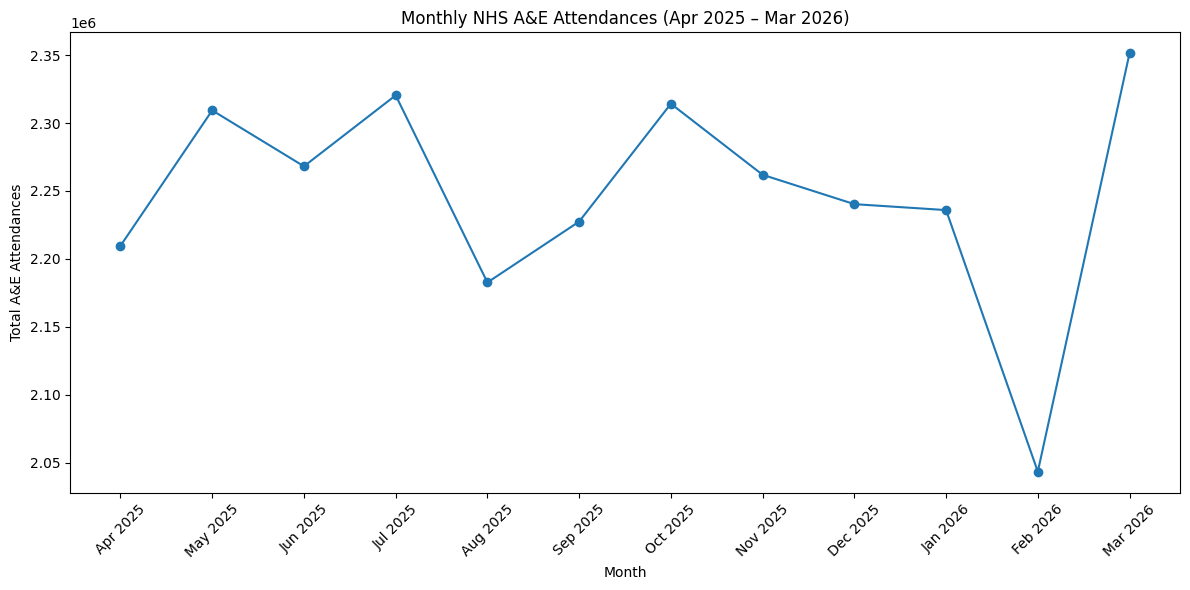

In [25]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_summary["period_month"],
    monthly_summary["total_ae_attendances"],
    marker="o"
)

plt.title("Monthly NHS A&E Attendances (Apr 2025 – Mar 2026)")
plt.xlabel("Month")
plt.ylabel("Total A&E Attendances")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

### Interpretation

Monthly A&E attendance volumes remained consistently high throughout the study period, ranging between approximately 2.0 million and 2.35 million attendances per month.

Attendance activity appeared relatively stable overall, although some variation was visible across the year.

March 2026 recorded the highest attendance volume, while February 2026 recorded the lowest attendance volume within the study period.

The consistently high attendance levels suggest sustained operational demand across NHS urgent and emergency care services throughout the year.

## Monthly 4-Hour Performance Trends

The NHS 4-hour standard measures the proportion of patients admitted, transferred or discharged within four hours of arrival in A&E.

This metric is widely used as a key indicator of operational performance and emergency department pressure across NHS urgent and emergency care services.

Lower performance rates may reflect:
- increased emergency demand
- crowding
- inpatient flow delays
- discharge bottlenecks
- wider system pressure

The following chart visualises monthly national 4-hour performance across the study period.

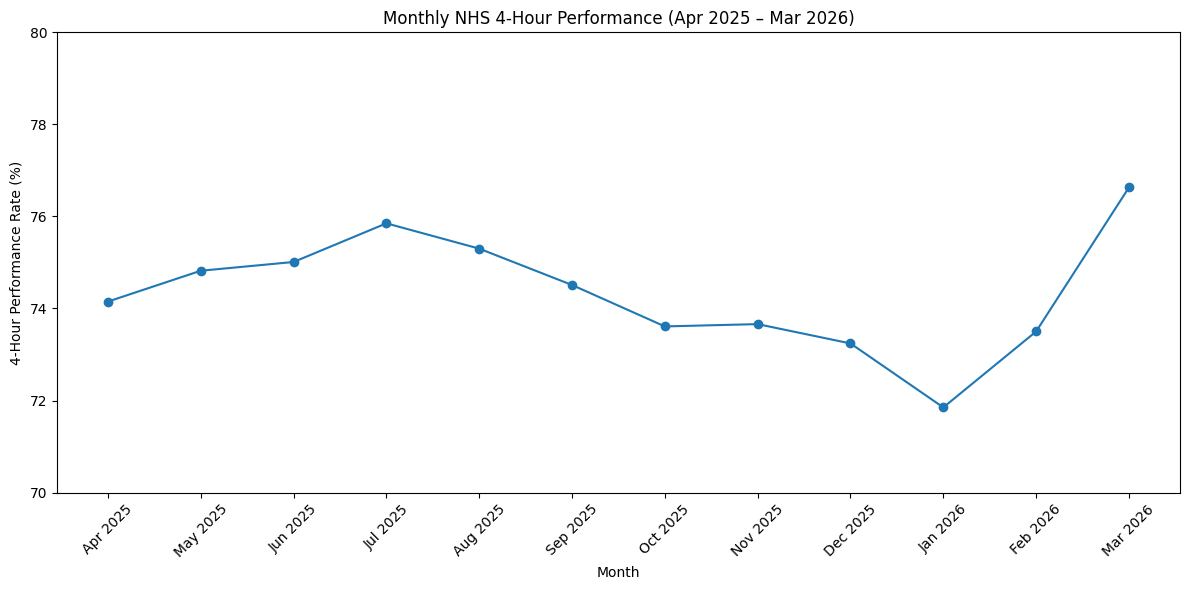

In [26]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_summary["period_month"],
    monthly_summary["four_hour_performance_rate"],
    marker="o"
)

plt.title("Monthly NHS 4-Hour Performance (Apr 2025 – Mar 2026)")
plt.xlabel("Month")
plt.ylabel("4-Hour Performance Rate (%)")

plt.ylim(70, 80)

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

### Interpretation

National 4-hour performance remained consistently below the historical NHS operational target throughout the study period.

Performance appeared relatively more stable during summer months before deteriorating during winter.

The lowest national performance level occurred during January 2026, coinciding with the highest observed level of prolonged decision-to-admit waiting times.

This pattern may suggest increasing operational pressure and inpatient flow challenges during winter months across NHS urgent and emergency care services.

## Relationship Between Emergency Demand and 4-Hour Performance

Operational pressure within emergency departments may increase during periods of higher attendance demand.

This section explores the relationship between:
- total A&E attendances
- national 4-hour performance

The analysis aims to investigate whether periods of higher emergency activity are associated with lower operational performance.

A scatter plot and correlation analysis are used to explore this relationship.

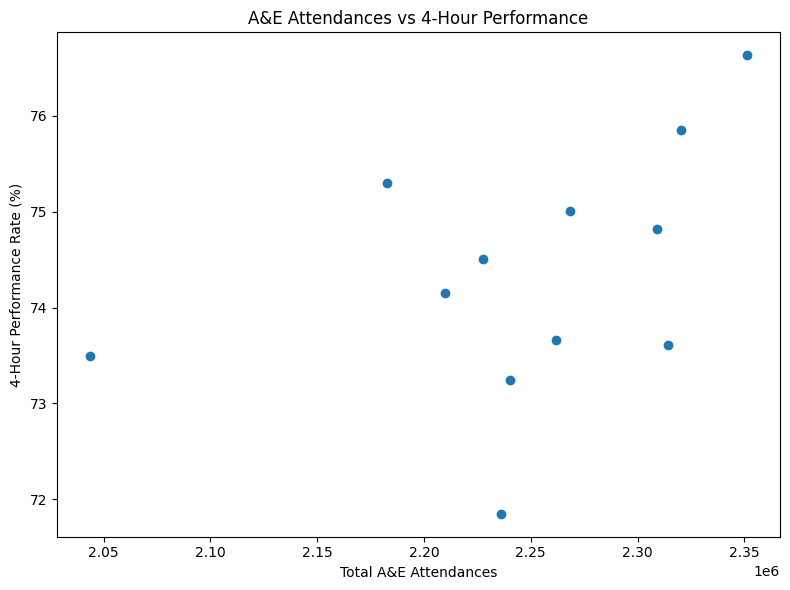

In [27]:
plt.figure(figsize=(8, 6))

plt.scatter(
    monthly_summary["total_ae_attendances"],
    monthly_summary["four_hour_performance_rate"]
)

plt.title("A&E Attendances vs 4-Hour Performance")
plt.xlabel("Total A&E Attendances")
plt.ylabel("4-Hour Performance Rate (%)")

plt.tight_layout()

plt.show()

In [28]:
correlation = monthly_summary[[
    "total_ae_attendances",
    "four_hour_performance_rate"
]].corr()

correlation

,total_ae_attendances,four_hour_performance_rate
total_ae_attendances,1.00000,0.41794
four_hour_performance_rate,0.41794,1.00000


### Interpretation

The scatter plot suggests a weak negative relationship between total A&E attendances and 4-hour performance.

This indicates that periods of higher emergency demand may be associated with lower operational performance, although the relationship does not appear particularly strong.

The correlation analysis suggests that emergency attendance demand alone may not fully explain variation in 4-hour performance.

Other operational factors such as:
- inpatient bed availability
- discharge delays
- workforce pressures
- patient complexity
- hospital flow challenges

may also contribute to operational performance variation across the NHS urgent and emergency care system.

## Provider-Level 4-Hour Performance Benchmarking

Operational performance can vary significantly between NHS provider organisations due to differences in:
- emergency demand
- hospital size
- inpatient capacity
- patient complexity
- workforce pressures
- local healthcare system factors

This section explores variation in average 4-hour performance across NHS provider organisations during the study period.


In [29]:
provider_performance_summary = (
    ae.groupby("org_name")
    .agg({
        "four_hour_performance_rate": "mean",
        "total_ae_attendances": "sum"
    })
    .reset_index()
)

provider_performance_summary = (
    provider_performance_summary
    .sort_values("four_hour_performance_rate")
)

provider_performance_summary.head(10)

,org_name,four_hour_performance_rate,total_ae_attendances
42,EAST CHESHIRE NHS TRUST,46.893910,53202
176,THE SHREWSBURY AND TELFORD HOSPITAL NHS TRUST,51.994099,160372
141,ROYAL UNITED HOSPITALS BATH NHS FOUNDATION TRUST,58.050840,107136
119,NOTTINGHAM UNIVERSITY HOSPITALS NHS TRUST,58.109900,233327
70,HULL UNIVERSITY TEACHING HOSPITALS NHS TRUST,58.805813,169370
201,WIRRAL UNIVERSITY TEACHING HOSPITAL NHS FOUNDA...,59.776751,129342
101,MID CHESHIRE HOSPITALS NHS FOUNDATION TRUST,59.955888,120332
162,SURREY AND SUSSEX HEALTHCARE NHS TRUST,60.540653,127380
29,COUNTESS OF CHESTER HOSPITAL NHS FOUNDATION TRUST,61.407604,92778
164,TAMESIDE AND GLOSSOP INTEGRATED CARE NHS FOUND...,61.890760,134368


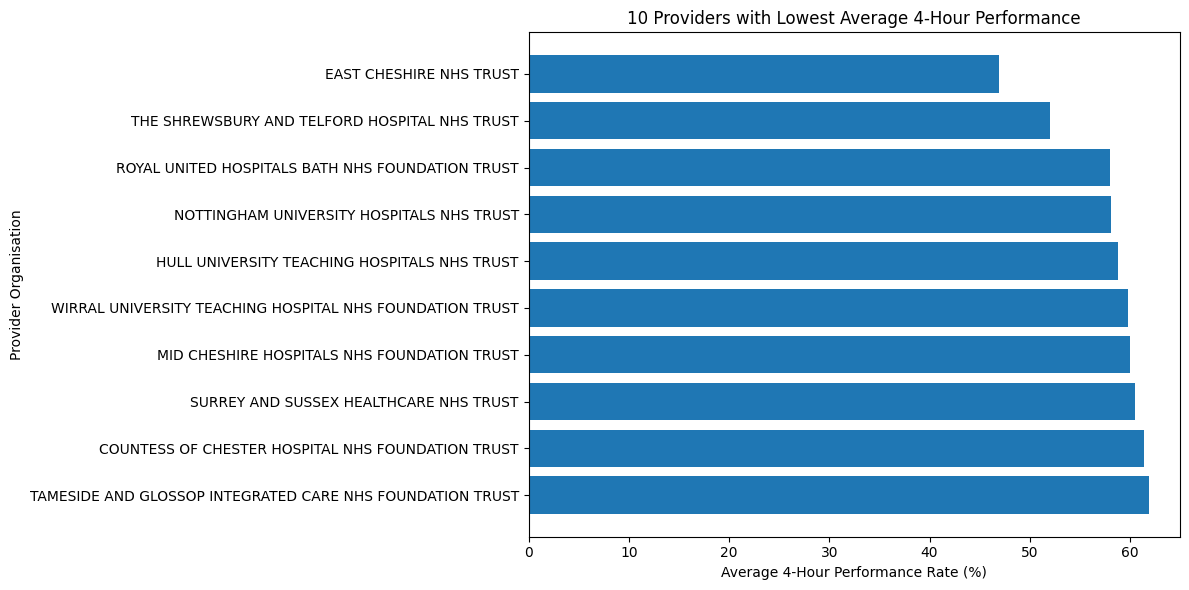

In [30]:
lowest_10_providers = provider_performance_summary.head(10)

plt.figure(figsize=(12, 6))

plt.barh(
    lowest_10_providers["org_name"],
    lowest_10_providers["four_hour_performance_rate"]
)

plt.title("10 Providers with Lowest Average 4-Hour Performance")
plt.xlabel("Average 4-Hour Performance Rate (%)")
plt.ylabel("Provider Organisation")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

### Interpretation

The analysis demonstrates substantial variation in average 4-hour performance across NHS provider organisations.

Several providers recorded considerably lower average performance levels compared with the wider national pattern.

Lower operational performance may reflect a combination of:
- sustained emergency demand
- inpatient flow challenges
- bed capacity pressures
- workforce constraints
- local healthcare system pressures

However, provider-level variation should be interpreted cautiously because NHS organisations differ substantially in:
- size
- case complexity
- service configuration
- specialist activity
- regional demand pressures.

## Decision-to-Admit (DTA) Waiting Analysis

Decision-to-admit (DTA) waiting times measure the time patients spend waiting in A&E after a clinical decision has been made to admit them into hospital.

Prolonged DTA waits are considered important indicators of:
- inpatient bed pressure
- delayed patient flow
- operational congestion
- wider system strain

This section analyses national trends in prolonged DTA waiting times across the study period.

Particular attention is given to:
- 12+ hour waits after decision to admit
- provider-level variation in DTA pressures

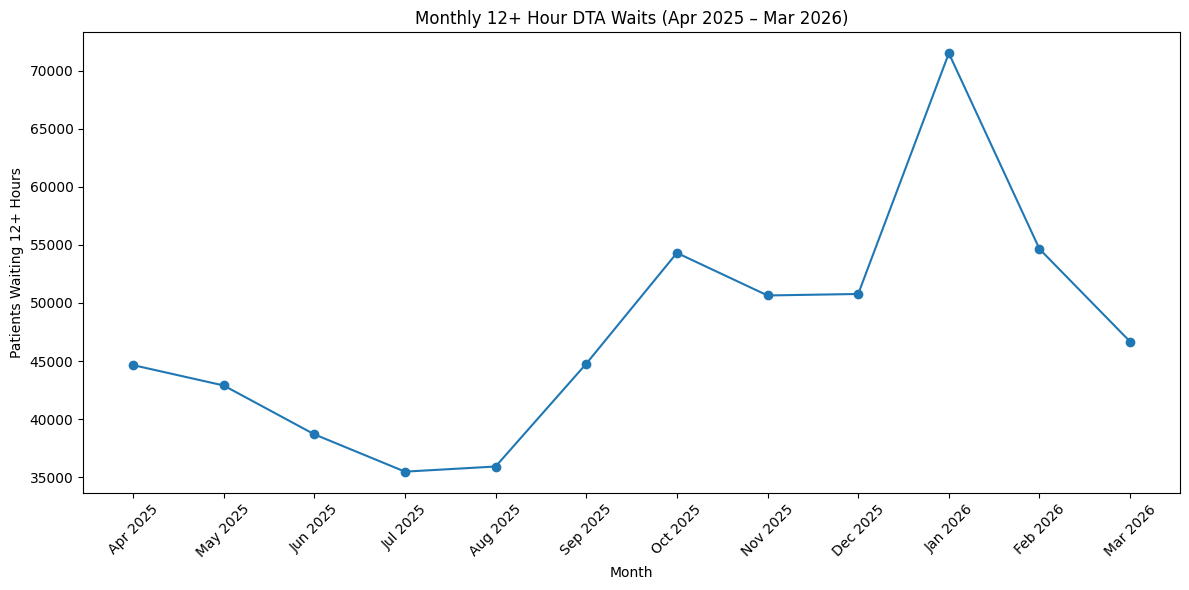

In [31]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_summary["period_month"],
    monthly_summary["patients_who_have_waited_12+_hrs_from_dta_to_admission"],
    marker="o"
)

plt.title("Monthly 12+ Hour DTA Waits (Apr 2025 – Mar 2026)")
plt.xlabel("Month")
plt.ylabel("Patients Waiting 12+ Hours")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

### Interpretation

12+ hour decision-to-admit waits increased substantially during winter months across the study period.

The highest level of prolonged DTA waits occurred during January 2026, coinciding with the lowest observed national 4-hour performance level.

This pattern may indicate increased inpatient flow pressure and reduced hospital capacity during winter months.

The results suggest that operational performance challenges within urgent and emergency care may be influenced not only by emergency attendance demand, but also by wider hospital flow pressures affecting admitted patients.

## Provider-Level DTA Benchmarking

This section identifies provider organisations recording the highest number of prolonged 12+ hour decision-to-admit waits across the study period.

The analysis aims to explore variation in inpatient flow pressure across NHS provider organisations.

In [32]:
provider_dta_summary = (
    ae.groupby("org_name")
    .agg({
        "patients_who_have_waited_4-12_hs_from_dta_to_admission": "sum",
        "patients_who_have_waited_12+_hrs_from_dta_to_admission": "sum",
        "total_dta_waits_over_4hrs": "sum",
        "total_ae_attendances": "sum"
    })
    .reset_index()
)

provider_dta_summary = (
    provider_dta_summary
    .sort_values(
        "patients_who_have_waited_12+_hrs_from_dta_to_admission",
        ascending=False
    )
)

provider_dta_summary.head(10)

,org_name,patients_who_have_waited_4-12_hs_from_dta_to_admission,patients_who_have_waited_12+_hrs_from_dta_to_admission,total_dta_waits_over_4hrs,total_ae_attendances
137,ROYAL FREE LONDON NHS FOUNDATION TRUST,12491,22650,35141,507130
183,UNIVERSITY HOSPITALS BIRMINGHAM NHS FOUNDATION...,32451,21023,53474,450266
176,THE SHREWSBURY AND TELFORD HOSPITAL NHS TRUST,5746,16915,22661,160372
43,EAST KENT HOSPITALS UNIVERSITY NHS FOUNDATION ...,5913,14153,20066,307425
115,NORTHERN CARE ALLIANCE NHS FOUNDATION TRUST,12557,13870,26427,425375
180,UNITED LINCOLNSHIRE TEACHING HOSPITALS NHS TRUST,10799,13254,24053,253436
9,BARTS HEALTH NHS TRUST,13320,12837,26157,534304
44,EAST LANCASHIRE HOSPITALS NHS TRUST,5452,12747,18199,294870
203,WORCESTERSHIRE ACUTE HOSPITALS NHS TRUST,11098,12165,23263,234375
85,LIVERPOOL UNIVERSITY HOSPITALS NHS FOUNDATION ...,16522,11762,28284,308985


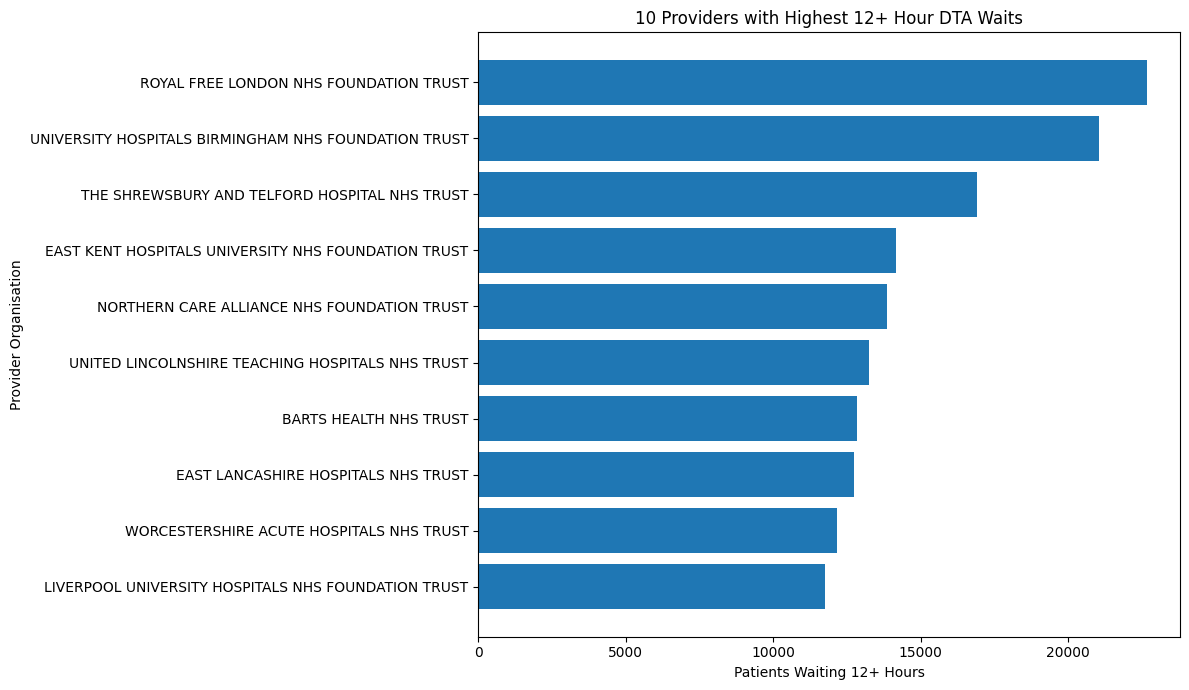

In [33]:
top_10_dta_providers = provider_dta_summary.head(10)

plt.figure(figsize=(12, 7))

plt.barh(
    top_10_dta_providers["org_name"],
    top_10_dta_providers["patients_who_have_waited_12+_hrs_from_dta_to_admission"]
)

plt.title("10 Providers with Highest 12+ Hour DTA Waits")
plt.xlabel("Patients Waiting 12+ Hours")
plt.ylabel("Provider Organisation")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

### Interpretation

Substantial variation was observed in prolonged 12+ hour decision-to-admit waits across NHS provider organisations.

Several providers recorded particularly high levels of prolonged DTA waits across the study period, suggesting sustained inpatient flow pressure.

Importantly, providers with the highest DTA waits were not always the providers with the highest emergency attendance volumes.

This may indicate that factors beyond emergency demand alone contribute to prolonged admitted-patient delays, including:
- inpatient bed availability
- discharge flow challenges
- hospital capacity constraints
- operational bottlenecks within wider healthcare systems

The findings suggest that prolonged DTA waits may reflect wider system-level patient-flow pressures rather than emergency department demand alone.

## Adjusted DTA Pressure Analysis

Raw DTA waiting totals may be influenced by overall hospital size and attendance volume.

To provide a fairer comparison between provider organisations, this section analyses prolonged 12+ hour DTA waits relative to total A&E attendances.

This adjusted metric aims to identify providers experiencing proportionally higher inpatient flow pressure relative to their emergency demand levels.

In [34]:
provider_dta_summary["dta_12hr_rate_per_1000_attendances"] = (
    provider_dta_summary[
        "patients_who_have_waited_12+_hrs_from_dta_to_admission"
    ] /
    provider_dta_summary["total_ae_attendances"]
) * 1000

provider_dta_summary = (
    provider_dta_summary
    .sort_values(
        "dta_12hr_rate_per_1000_attendances",
        ascending=False
    )
)

provider_dta_summary.head(10)

,org_name,patients_who_have_waited_4-12_hs_from_dta_to_admission,patients_who_have_waited_12+_hrs_from_dta_to_admission,total_dta_waits_over_4hrs,total_ae_attendances,dta_12hr_rate_per_1000_attendances
176,THE SHREWSBURY AND TELFORD HOSPITAL NHS TRUST,5746,16915,22661,160372,105.473524
195,WARRINGTON AND HALTON TEACHING HOSPITALS NHS F...,7893,10072,17965,118419,85.053919
29,COUNTESS OF CHESTER HOSPITAL NHS FOUNDATION TRUST,4735,7784,12519,92778,83.899200
42,EAST CHESHIRE NHS TRUST,2566,4105,6671,53202,77.158753
201,WIRRAL UNIVERSITY TEACHING HOSPITAL NHS FOUNDA...,6310,9311,15621,129342,71.987444
127,PORTSMOUTH HOSPITALS UNIVERSITY NHS TRUST,10092,11685,21777,176501,66.203591
49,EPSOM AND ST HELIER UNIVERSITY HOSPITALS NHS T...,7771,9944,17715,158195,62.859130
162,SURREY AND SUSSEX HEALTHCARE NHS TRUST,6482,7748,14230,127380,60.825875
114,NORTHAMPTON GENERAL HOSPITAL NHS TRUST,6683,8672,15355,157573,55.034809
101,MID CHESHIRE HOSPITALS NHS FOUNDATION TRUST,5881,6447,12328,120332,53.576771


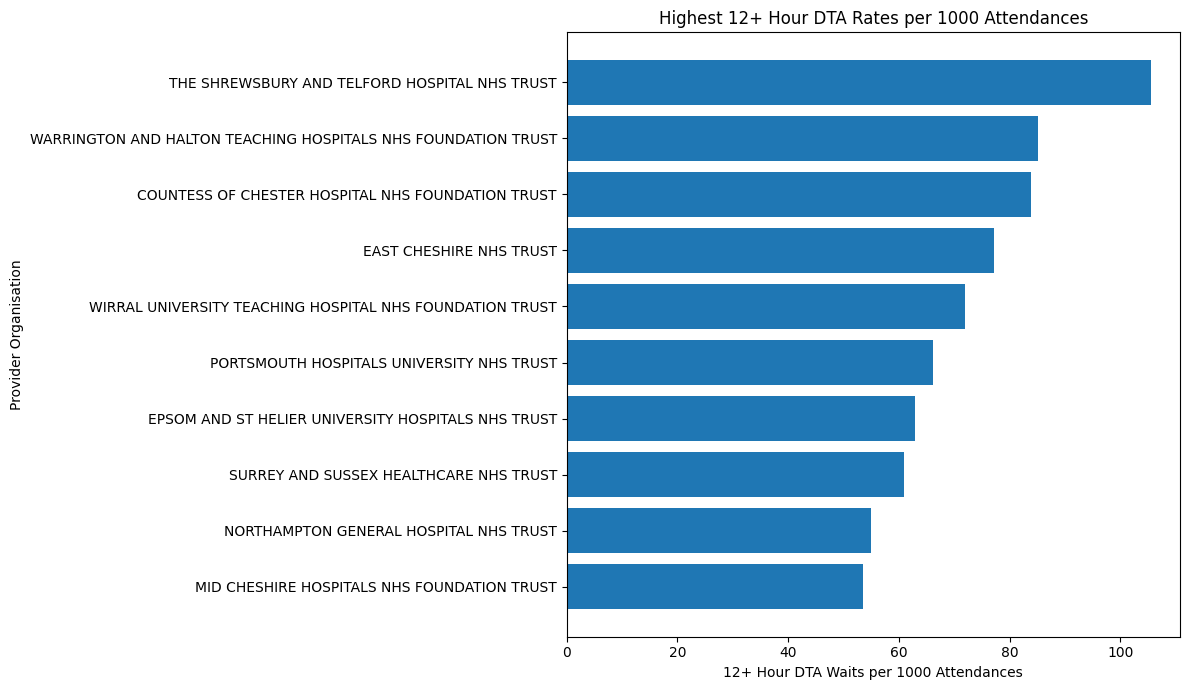

In [35]:
top_10_adjusted_dta = provider_dta_summary.head(10)

plt.figure(figsize=(12, 7))

plt.barh(
    top_10_adjusted_dta["org_name"],
    top_10_adjusted_dta["dta_12hr_rate_per_1000_attendances"]
)

plt.title("Highest 12+ Hour DTA Rates per 1000 Attendances")
plt.xlabel("12+ Hour DTA Waits per 1000 Attendances")
plt.ylabel("Provider Organisation")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

### Interpretation

Adjusting prolonged DTA waits relative to attendance volume revealed a different pattern of provider-level operational pressure.

Some organisations with relatively smaller attendance volumes demonstrated disproportionately high rates of prolonged admitted-patient waits.

This suggests that operational pressure may not be explained solely by emergency attendance demand.

The findings may reflect variation in:
- inpatient bed availability
- discharge flow efficiency
- local system pressures
- operational capacity
- hospital flow management processes

Rate-adjusted analysis provides a more balanced comparison of provider-level operational pressure across NHS organisations of different sizes.

## Relationship Between DTA Pressure and 4-Hour Performance

Previous sections suggested that prolonged decision-to-admit waits may reflect wider inpatient flow pressures within hospitals.

This section explores the relationship between:
- prolonged 12+ hour DTA waits
- average 4-hour operational performance

The aim is to investigate whether providers experiencing greater admitted-patient delays also tend to demonstrate lower emergency department performance.

In [36]:
provider_correlation = (
    ae.groupby("org_name")
    .agg({
        "patients_who_have_waited_12+_hrs_from_dta_to_admission": "sum",
        "four_hour_performance_rate": "mean"
    })
    .reset_index()
)

provider_correlation.head()

,org_name,patients_who_have_waited_12+_hrs_from_dta_to_admission,four_hour_performance_rate
0,AIREDALE NHS FOUNDATION TRUST,2139,63.748963
1,ALDER HEY CHILDREN'S NHS FOUNDATION TRUST,0,85.340871
2,ASHFORD AND ST PETER'S HOSPITALS NHS FOUNDATIO...,3293,65.220545
3,ASHFORD WALK-IN-CENTRE,0,96.468199
4,ASSURA VERTIS URGENT CARE CENTRES (BIRMINGHAM),0,100.000000


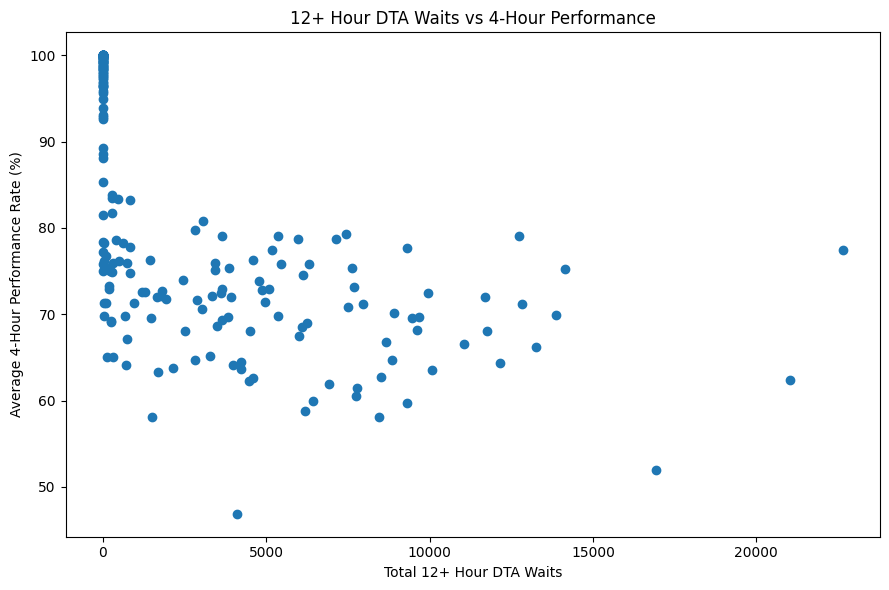

In [37]:
plt.figure(figsize=(9, 6))

plt.scatter(
    provider_correlation[
        "patients_who_have_waited_12+_hrs_from_dta_to_admission"
    ],
    provider_correlation[
        "four_hour_performance_rate"
    ]
)

plt.title("12+ Hour DTA Waits vs 4-Hour Performance")
plt.xlabel("Total 12+ Hour DTA Waits")
plt.ylabel("Average 4-Hour Performance Rate (%)")

plt.tight_layout()

plt.show()

In [38]:
provider_correlation[[
    "patients_who_have_waited_12+_hrs_from_dta_to_admission",
    "four_hour_performance_rate"
]].corr()

,patients_who_have_waited_12+_hrs_from_dta_to_admission,four_hour_performance_rate
patients_who_have_waited_12+_hrs_from_dta_to_admission,1.000000,-0.587014
four_hour_performance_rate,-0.587014,1.000000


### Interpretation

The analysis suggests a negative relationship between prolonged 12+ hour DTA waits and average 4-hour operational performance across NHS provider organisations.

Providers experiencing higher levels of prolonged admitted-patient delays generally appeared more likely to demonstrate lower average emergency department performance.

This finding supports the idea that emergency department performance may be influenced not only by emergency demand itself, but also by wider hospital flow pressures affecting admitted patients.

The results are consistent with the operational understanding that inpatient congestion and reduced bed availability can contribute to emergency department crowding and longer waiting times.

## Conclusions

This project analysed NHS England A&E operational performance data between April 2025 and March 2026 using provider-level urgent and emergency care datasets.

The analysis demonstrated consistently high national emergency attendance demand throughout the study period, with over two million attendances recorded each month across NHS provider organisations.

National 4-hour performance remained below historical operational targets throughout the year and deteriorated during winter months, particularly during January 2026.

Prolonged decision-to-admit waiting times also increased substantially during winter, suggesting increased inpatient flow pressure across NHS organisations.

Provider-level benchmarking demonstrated considerable variation in operational performance and DTA pressures between NHS organisations.

Importantly, providers with the highest admitted-patient delays were not always the providers with the largest emergency attendance volumes, suggesting that operational pressure may be influenced by wider system factors beyond emergency demand alone.

The analysis also demonstrated a negative relationship between prolonged admitted-patient delays and 4-hour operational performance, supporting the operational understanding that inpatient flow challenges and reduced hospital capacity can contribute to emergency department crowding and longer waits.

Overall, the findings suggest that NHS urgent and emergency care performance may be strongly influenced by wider patient-flow pressures affecting admitted patients, in addition to emergency attendance demand itself.

## Project Limitations

Several limitations should be considered when interpreting the findings from this analysis.

First, the analysis used aggregated provider-level operational data rather than patient-level datasets. As a result, the analysis cannot determine causal relationships between operational variables.

Second, NHS provider organisations vary substantially in:
- hospital size
- specialist activity
- patient complexity
- regional population characteristics
- local healthcare system pressures

which may influence operational performance comparisons.

Third, the analysis focused primarily on A&E operational metrics and did not include additional system-level variables such as:
- inpatient bed occupancy
- discharge delays
- staffing levels
- ambulance handover delays

which may also contribute to urgent and emergency care performance.

Finally, the analysis covered a single 12-month period and may not fully capture longer-term operational trends across NHS urgent and emergency care services.

## Exporting Clean Analytical Outputs

In [39]:
# Export cleaned master dataset
ae.to_csv(
    "C:/Users/raahu/OneDrive/Desktop/nhs-ae-patient-flow-analysis/data_cleaned/ae_clean_master.csv",
    index=False
)

# Export monthly summary
monthly_summary.to_csv(
    "C:/Users/raahu/OneDrive/Desktop/nhs-ae-patient-flow-analysis/outputs/monthly_summary.csv",
    index=False
)

# Export provider DTA summary
provider_dta_summary.to_csv(
    "C:/Users/raahu/OneDrive/Desktop/nhs-ae-patient-flow-analysis/outputs/provider_dta_summary.csv",
    index=False
)

## Key Findings Summary

The analysis identified several important operational patterns across NHS urgent and emergency care services during the study period:

### 1. Sustained National Emergency Demand
National A&E attendance volumes remained consistently high throughout the year, with more than two million attendances recorded each month.

### 2. Winter Operational Deterioration
National 4-hour performance deteriorated during winter months, with January 2026 recording the lowest observed performance level.

### 3. Increased Winter DTA Pressure
Prolonged 12+ hour decision-to-admit waits increased substantially during winter, suggesting increased inpatient flow pressure across NHS organisations.

### 4. Significant Provider-Level Variation
Substantial variation was observed between NHS provider organisations in both operational performance and prolonged DTA waits.

### 5. Attendance Demand Alone Did Not Fully Explain Pressure
Providers with the highest prolonged DTA waits were not always the providers with the largest attendance volumes, suggesting wider hospital flow pressures may contribute significantly to operational strain.

### 6. Relationship Between DTA Pressure and Performance
Providers experiencing greater prolonged admitted-patient delays generally demonstrated lower average 4-hour operational performance.

## Future Work

This project focused primarily on provider-level A&E operational performance metrics.

Future analytical work could extend the analysis by incorporating additional NHS operational datasets related to:
- inpatient bed occupancy
- delayed discharge
- ambulance handover delays
- workforce pressures
- urgent and emergency care sitrep data

Integrating these datasets may provide a more comprehensive understanding of:
- patient-flow dynamics
- hospital capacity pressures
- wider system-level operational challenges across NHS urgent and emergency care services.

Potential future analysis could also include:
- predictive modelling
- seasonal forecasting
- trust clustering analysis
- time-series modelling
- interactive operational dashboards using Tableau or Power BI.